# LeJEPA Pretraining on Industrial Sensor Data

A self-supervised pretraining run for `self_supervised_physical_ai`: an I-JEPA-style
encoder trained with a context->target prediction loss plus a **SIGReg** regularizer
(Balestriero & LeCun, ["LeJEPA: Provable and Scalable Self-Supervised Learning
Without the Heuristics"](https://arxiv.org/abs/2511.08544)) instead of the
EMA / stop-gradient / teacher-student heuristics of classic JEPA.

This trains on `SyntheticSEFCDataset` — synthetic multivariate sensor windows with
three injected "operating regimes" (distinct frequency/amplitude combinations) — so
we can sanity-check that the embedding space actually separates something before
pointing the pipeline at real FactoryNet data.

**Deliberate design choices this run inherits from the package (see
`self_supervised_physical_ai.lejepa` for the full list) — not settled decisions:**

1. I-JEPA-style patch masking + predictor, not LeJEPA's original view-augmentation
   (global/local crop) setup.
2. No stop-gradient on the target branch by default (`detach_target=False`) — SIGReg
   alone is claimed to prevent collapse; worth A/B testing against
   `detach_target=True` on real data.
3. A mask shared across the batch, not per-sample — the first thing to fix before
   any real training run.
4. SIGReg regularizes the *per-patch* embedding distribution (all patches, flattened
   across the batch), not a pooled per-window summary.


In [1]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from self_supervised_physical_ai import LeJEPAConfig, LeJEPAModel, SyntheticSEFCDataset

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

## Config, data, and model

In [2]:
cfg = LeJEPAConfig(
    n_channels=4,
    window_len=256,
    patch_len=16,
    d_model=64,
    n_heads=4,
    n_layers=3,
    predictor_d_model=32,
    predictor_n_heads=4,
    predictor_n_layers=2,
    batch_size=32,
    lr=3e-4,
    epochs=3,
)
cfg


LeJEPAConfig(n_channels=4, window_len=256, patch_len=16, d_model=64, n_heads=4, n_layers=3, ff_mult=4, dropout=0.1, predictor_d_model=32, predictor_n_heads=4, predictor_n_layers=2, context_ratio=0.6, n_target_blocks=4, sigreg_n_directions=64, sigreg_n_freqs=8, sigreg_lambda=1.0, batch_size=32, lr=0.0003, weight_decay=0.05, epochs=3)

In [3]:
dataset = SyntheticSEFCDataset(n_windows=2000, n_channels=cfg.n_channels, window_len=cfg.window_len)
loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)

model = LeJEPAModel(cfg).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

sum(p.numel() for p in model.parameters())


183936

## Training loop

Tracks the three loss components per epoch so we can plot them below.

In [4]:
history = {"total": [], "pred": [], "sigreg": []}

for epoch in range(cfg.epochs):
    model.train()
    running = {"total": 0.0, "pred": 0.0, "sigreg": 0.0}
    n_batches = 0
    for batch in loader:
        x = batch["x"].to(device)
        sr = batch["sample_rate_hz"].to(device)

        out = model(x, sr)
        opt.zero_grad()
        out.loss.backward()
        opt.step()

        running["total"] += out.loss.item()
        running["pred"] += out.pred_loss.item()
        running["sigreg"] += out.sigreg_loss.item()
        n_batches += 1

    for key in history:
        history[key].append(running[key] / n_batches)

    print(
        f"epoch {epoch}: "
        f"total={history['total'][-1]:.4f} "
        f"pred={history['pred'][-1]:.4f} "
        f"sigreg={history['sigreg'][-1]:.4f}"
    )


epoch 0: total=0.4037 pred=0.2788 sigreg=0.1249


epoch 1: total=0.2890 pred=0.1942 sigreg=0.0947


epoch 2: total=0.2094 pred=0.1431 sigreg=0.0663


## Loss curves

Three small multiples rather than one dual-axis chart — `pred_loss` and
`sigreg_loss` sit on different scales, and `total = pred_loss + sigreg_lambda *
sigreg_loss`, so overlaying them on a shared axis would be misleading.


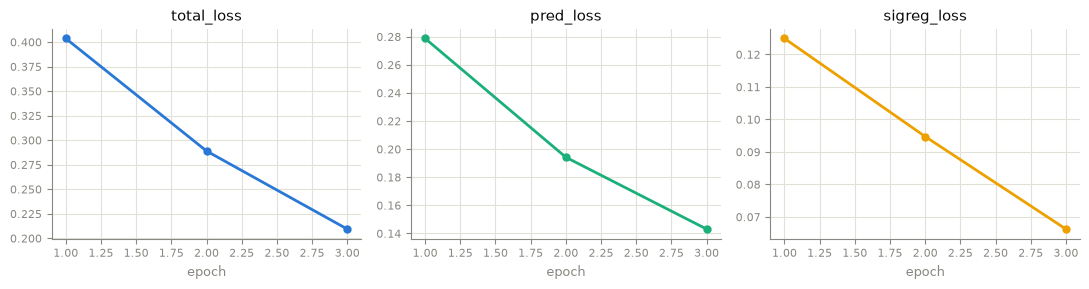

In [5]:
# Palette: fixed categorical order (blue / aqua / yellow), light-surface chart chrome.
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
SERIES = {"total": "#2a78d6", "pred": "#1baf7a", "sigreg": "#eda100"}

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharex=True)
epochs = range(1, cfg.epochs + 1)

for ax, key in zip(axes, ["total", "pred", "sigreg"]):
    ax.plot(epochs, history[key], color=SERIES[key], linewidth=2, marker="o", markersize=5)
    ax.set_title(f"{key}_loss", color=INK_PRIMARY, fontsize=11)
    ax.set_xlabel("epoch", color=INK_MUTED, fontsize=9)
    ax.grid(True, color=GRIDLINE, linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(INK_MUTED)
    ax.tick_params(colors=INK_MUTED, labelsize=8)

fig.tight_layout()
plt.show()


## Sanity check: do embeddings separate the synthetic regimes?

Not the primary evaluation — just a quick qualitative check that the pretraining
pipeline is doing *something* sensible before trusting it on real FactoryNet data.
We mean-pool each window's patch embeddings (full unmasked encoder pass) into a
single vector, project to 2D with PCA, and color by the (synthetic, ground-truth)
regime label the model never saw.


In [6]:
model.eval()
eval_loader = DataLoader(dataset, batch_size=128, shuffle=False)

pooled_embeddings = []
regimes = []
with torch.no_grad():
    for batch in eval_loader:
        x = batch["x"].to(device)
        sr = batch["sample_rate_hz"].to(device)
        patch_emb = model.encoder(x, sr)  # (b, n_patches, d_model)
        pooled_embeddings.append(patch_emb.mean(dim=1).cpu())
        regimes.append(batch["regime"])

pooled_embeddings = torch.cat(pooled_embeddings)
regimes = torch.cat(regimes)

centered = pooled_embeddings - pooled_embeddings.mean(dim=0, keepdim=True)
_, _, v = torch.pca_lowrank(centered, q=2)
coords_2d = (centered @ v[:, :2]).numpy()


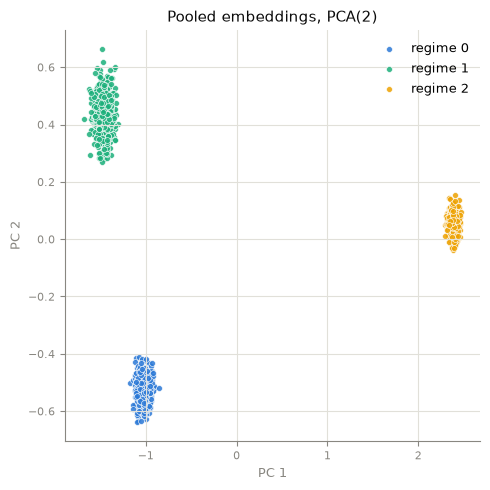

In [7]:
REGIME_COLORS = ["#2a78d6", "#1baf7a", "#eda100"]  # fixed categorical order, slots 1-3

fig, ax = plt.subplots(figsize=(5, 5))
for regime in sorted(regimes.unique().tolist()):
    mask = regimes == regime
    ax.scatter(
        coords_2d[mask, 0],
        coords_2d[mask, 1],
        s=18,
        linewidths=0.5,
        edgecolors="white",
        color=REGIME_COLORS[regime],
        label=f"regime {regime}",
        alpha=0.85,
    )

ax.set_title("Pooled embeddings, PCA(2)", color=INK_PRIMARY, fontsize=11)
ax.set_xlabel("PC 1", color=INK_MUTED, fontsize=9)
ax.set_ylabel("PC 2", color=INK_MUTED, fontsize=9)
ax.grid(True, color=GRIDLINE, linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(INK_MUTED)
ax.tick_params(colors=INK_MUTED, labelsize=8)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()


## Next steps

- Swap `SyntheticSEFCDataset` for `FactoryNetWindowDataset` once the real file
  layout, sample-rate field, and S-E-F-C column mapping are confirmed (see the
  `TODO`s on that class).
- A/B test `detach_target=True` against the current no-stop-gradient default.
- Move from a shared batch mask (`sample_shared_mask`) to per-sample masking.
- If regimes don't separate cleanly above, that's a debugging signal — not
  necessarily a sign the architecture is wrong; check `sigreg_lambda`,
  `context_ratio`, and training length before changing the model itself.
